# Conclusiones del diseño de unidades

*Resumen de lo que se decidió abajo, para no releer el notebook completo.*

## Lo que queda fijo

| Decisión | Valor |
| --- | --- |
| Radios a analizar | 100, 150, 200, 250 y 300 m |
| Radio que sostiene la tesis | 300 m |
| Forma de la unidad | círculo del radio correspondiente |
| Regla de fusión | dos cámaras se fusionan si comparten más de **60%** del área **a 300 m** (equivale a 192 m entre ellas) |
| Unidades tratadas | **99**, a partir de 113 cámaras |
| Incidentes en área compartida | se reparten en partes iguales: 1/2 si caen en dos círculos, 1/3 si caen en tres |

Los grupos se calculan **una sola vez a 300 m** y se reusan en todos los radios.
Por eso el `unidad_id` significa lo mismo en las cinco corridas, que era el
problema original: antes cada radio reconstruía su grid y no eran comparables.

## Por qué 60% y no otro umbral

Queda acotado por los dos lados, así que no es una preferencia:

- **Por abajo:** con 50% dos cámaras quedan fuera del círculo de su propia
  unidad a 100 m. Una unidad tratada sin su cámara adentro no es una unidad
  tratada. Con 60% la cámara más lejana queda a 81 m de su centro.
- **Por arriba:** con 70% ya reaparece un par traslapado a 100 m, y el conteo
  doble a 300 m solo mejora de 5.5% a 6.6%.

## Qué se verificó

- Ninguna cámara queda fuera de su unidad en el radio más chico.
- Todas las unidades son círculos del mismo radio, así que tienen la misma área
  y son comparables entre sí y con los controles.
- La suma de los conteos ponderados coincide exactamente con el número real de
  incidentes: 44,153 a 300 m, contra 46,730 del conteo ingenuo.

## Robustez pendiente de correr

1. **X = 50%** — fusiona el par límite del Periférico; si los coeficientes no se
   mueven, el umbral no está cargando el resultado.
2. **Excluir las 2 unidades con la cámara al borde** (2.9% de los incidentes
   tratados). Van en la muestra principal porque excluirlas seleccionaría por
   densidad de cámaras.
3. **Partir el espacio por centro más cercano** en vez de repartir pesos.

## Limitaciones conocidas

**Ambigüedad vertical.** Los incidentes solo traen latitud y longitud, así que no
hay forma de saber si ocurrieron en un segundo piso o en la vía de abajo. 42% de
las cámaras tienen vías de más de un nivel dentro de su círculo de 300 m. Esto
mete al conteo incidentes que la cámara no puede afectar, lo que **diluye el
efecto hacia cero**: si aun así aparece una reducción significativa, el efecto
real sería mayor. Mitigación posible: meter la composición de niveles como
covariable del propensity score, para que cada tratada se empareje con controles
que tengan la misma ambigüedad.

**El par que se salvó por 13 metros.** Las unidades 77 y 32 son dos cámaras del
mismo tramo del Periférico segundo piso, sentido sur-norte. Comparten 57.3% de
su área y sus centros están a 205 m, contra el umbral de 192 m. Conceptualmente
deberían ser una sola unidad; la regla las dejó separadas. Cubierto por la
robustez con X=50%.

**5.5% de incidentes compartidos a 300 m.** El reparto proporcional arregla la
aritmética, pero dos unidades vecinas siguen registrando los mismos eventos a
medias, así que sus resultados están ligados. Con 89% de los incidentes en peso
1, es de segundo orden.

**Los pesos fraccionarios no sirven para modelos de conteo.** Funcionan con MCO
sobre conteos o tasas, que es la especificación del capítulo 2. Cambiar a Poisson
obligaría a replantear el reparto.

---

Ninguna de estas limitaciones se resuelve con los datos disponibles. Están
documentadas para poder declararlas en el texto en vez de que las encuentre
quien lea la tesis.

# Diseñando unidades de análisis 
Un problema al que me enfrentaba era que mis unidades analizadas no eran comparables la una con la otra a medida que el radio aumentaba porque el grid se creaba desde cero para cada una. Esto imposibilita el comparar los efectos realmente, y vuelve cada radio su propio análisis. Se busca ahora dar más continuidad y mejorar el diseño, para lo cual es necesario que exista consistencia entre los análisis. Aquí se vuelve un tanto problemático porque queremos que las unidades sean comparables entre sí también en sus características en todos los radios. El primer paso es definir los centros. La construcción inicial consistía en un mapeo a partir de cada cámara, pero creo que lo más conveniente es que se haga más bien de forma estructurada para el radio más grande y vemos qué tan comparables son. 

In [1]:
from nbsetup import *
from pipeline import Datos

In [2]:
datos = Datos()

In [3]:
# Primer approach: un círculo sobre cada cámara, sin juntar círculos con overlap. 
# El radio es parámetro, y el camara_id NO depende de él: así el mismo id
# apunta a la misma cámara en todos los radios, que es justo lo que faltaba
# cuando el grid se reconstruía desde cero para cada uno.

def construir_circulos(camaras, radio_m, tratado=True):
    """Un círculo por cámara, del radio pedido.

    El id sale del orden del shapefile, no de la geometría ni del radio: es
    estable entre radios mientras el archivo de cámaras no cambie.
    Devuelve el centro aparte para poder reconstruir cualquier radio después.
    """
    return gpd.GeoDataFrame(
        {
            "camara_id": range(len(camaras)),
            "radio_m": radio_m,
            "tratado": tratado,
            "centro": camaras.geometry.values,
        },
        geometry=camaras.geometry.buffer(radio_m).values,
        crs=camaras.crs,
    )


circulos = construir_circulos(datos.camaras, radio_m=300)
circulos.head()

,camara_id,radio_m,tratado,centro,geometry
0,0,300,True,POINT (2801634.246 826106.772),"POLYGON ((2801934.246 826106.772, 2801932.802 ..."
1,1,300,True,POINT (2794877.865 826232.277),"POLYGON ((2795177.865 826232.277, 2795176.42 8..."
2,2,300,True,POINT (2800396.204 828065.074),"POLYGON ((2800696.204 828065.074, 2800694.759 ..."
3,3,300,True,POINT (2799581.703 830917.981),"POLYGON ((2799881.703 830917.981, 2799880.258 ..."
4,4,300,True,POINT (2793345.907 820272.279),"POLYGON ((2793645.907 820272.279, 2793644.462 ..."


## Cuánto se traslapan

El approach de un círculo por cámara sirve para empezar, pero hay que medir el
precio: los círculos se pisan entre sí, y un incidente en la zona compartida
cuenta para las dos unidades. Eso infla los conteos y rompe el supuesto de que
las unidades son independientes.

In [4]:
# para cada radio: cuántas cámaras comparten área con otra, y cuánta área se
# está contando doble (la suma de áreas contra el área de la unión)
def diagnostico_traslape(camaras, radios):
    filas = []
    for r in radios:
        c = construir_circulos(camaras, r)
        pares = gpd.sjoin(c, c, predicate="intersects")
        pares = pares[pares.camara_id_left < pares.camara_id_right]
        afectadas = set(pares.camara_id_left) | set(pares.camara_id_right)
        area = c.area.sum() / 1e6
        union = c.union_all().area / 1e6
        filas.append({
            "radio_m": r,
            "camaras_con_traslape": len(afectadas),
            "pct_camaras": len(afectadas) / len(c),
            "pares": len(pares),
            "area_suma_km2": area,
            "area_union_km2": union,
            "pct_area_duplicada": 1 - union / area,
        })
    return pd.DataFrame(filas)


traslape = diagnostico_traslape(datos.camaras, [50, 100, 150, 200, 250, 300])
traslape.style.format({
    "pct_camaras": "{:.0%}", "pct_area_duplicada": "{:.0%}",
    "area_suma_km2": "{:,.1f}", "area_union_km2": "{:,.1f}",
})

,radio_m,camaras_con_traslape,pct_camaras,pares,area_suma_km2,area_union_km2,pct_area_duplicada
0,50,22,19%,14,0.9,0.8,5%
1,100,26,23%,16,3.5,3.3,8%
2,150,31,27%,20,8.0,7.2,9%
3,200,39,35%,26,14.2,12.6,11%
4,250,49,43%,36,22.2,19.3,13%
5,300,58,51%,45,31.9,27.2,15%


In [5]:
# los incidentes que caen en más de un círculo, que es el conteo doble en concreto
def incidentes_duplicados(incidentes, camaras, radios):
    filas = []
    for r in radios:
        c = construir_circulos(camaras, r)
        dentro = gpd.sjoin(incidentes, c[["camara_id", "geometry"]], predicate="within")
        filas.append({
            "radio_m": r,
            "incidentes_en_circulos": dentro.index.nunique(),
            "asignaciones": len(dentro),
            "pct_contados_de_mas": 1 - dentro.index.nunique() / len(dentro),
        })
    return pd.DataFrame(filas)


dup = incidentes_duplicados(datos.incidentes, datos.camaras, [50, 100, 150, 200, 250, 300])
dup.style.format({"pct_contados_de_mas": "{:.1%}", 
                  "incidentes_en_circulos": "{:,}", "asignaciones": "{:,}"})

,radio_m,incidentes_en_circulos,asignaciones,pct_contados_de_mas
0,50,"10,949","12,359",11.4%
1,100,"16,742","19,965",16.1%
2,150,"21,951","26,314",16.6%
3,200,"28,267","33,743",16.2%
4,250,"37,018","44,691",17.2%
5,300,"45,019","55,264",18.5%


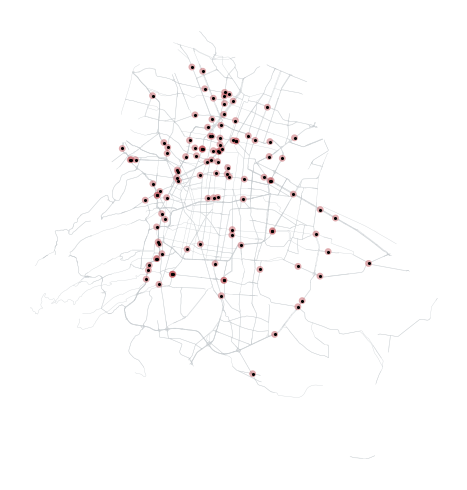

In [6]:
# cómo se ve a 300 m
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_axis_off()
datos.vialidades.plot(ax=ax, linewidth=.2, color="#C4CACE", zorder=1)
construir_circulos(datos.camaras, 300).plot(
    ax=ax, facecolor="#BC4B51", edgecolor="none", alpha=.45, zorder=2
)
datos.camaras.plot(ax=ax, markersize=1.5, color="black", zorder=3)
fig.tight_layout()
plt.show()

## Quiénes se traslapan, y cuánto

El 15% de área duplicada a 300 m es un promedio sobre toda la ciudad, y esconde
lo que pasa en cada par: los que se tocan suelen tocarse mucho. Vale la pena ver
los casos concretos antes de decidir si el traslape se ignora o se trata.

In [7]:
RADIO_OVERLAP = 300


def pares_con_overlap(camaras, radio_m):
    """Todo par de círculos que se toca, con qué fracción de su área comparte.

    Como los círculos son del mismo radio, el porcentaje es el mismo para los dos
    miembros del par: el área de la intersección sobre el área de un círculo.
    """
    circulos = construir_circulos(camaras, radio_m)
    pares = gpd.sjoin(circulos, circulos, predicate="intersects").reset_index(drop=True)
    pares = pares[pares.camara_id_left < pares.camara_id_right]

    geometria = circulos.set_index("camara_id").geometry
    interseccion = [
        geometria.loc[a].intersection(geometria.loc[b])
        for a, b in zip(pares.camara_id_left, pares.camara_id_right)
    ]
    area_circulo = np.pi * radio_m ** 2

    return (
        pd.DataFrame({
            "camara_a": pares.camara_id_left.values,
            "camara_b": pares.camara_id_right.values,
            "via_a": camaras.via_princi.values[pares.camara_id_left],
            "via_b": camaras.via_princi.values[pares.camara_id_right],
            "distancia_m": [
                camaras.geometry.iloc[a].distance(camaras.geometry.iloc[b])
                for a, b in zip(pares.camara_id_left, pares.camara_id_right)
            ],
            "area_compartida_ha": [g.area / 1e4 for g in interseccion],
            "pct_overlap": [g.area / area_circulo for g in interseccion],
        })
        .sort_values("pct_overlap", ascending=False)
        .reset_index(drop=True)
    )


pares = pares_con_overlap(datos.camaras, RADIO_OVERLAP)
print(f"{len(pares)} pares se tocan a {RADIO_OVERLAP} m")

pares.style.format({
    "pct_overlap": "{:.1%}",
    "distancia_m": "{:,.0f}",
    "area_compartida_ha": "{:,.2f}",
}).hide(axis="index")

45 pares se tocan a 300 m


camara_a,camara_b,via_a,via_b,distancia_m,area_compartida_ha,pct_overlap
81,101,Eje 1 Norte,Insurgentes,0,28.23,99.8%
72,73,Autopista Urbana Norte (AUN),Autopista Urbana Norte (AUN),0,28.23,99.8%
52,100,Eje 5 Sur,Universidad,0,28.23,99.8%
9,82,Eje 1 Oriente,Eje 2 Norte,5,27.95,98.8%
84,107,Taxque?a,Eje 1 Oriente,17,27.20,96.2%
55,101,Eje 1 Norte,Insurgentes,56,24.88,88.0%
55,81,Eje 1 Norte,Eje 1 Norte,56,24.88,88.0%
7,100,Universidad,Universidad,66,24.29,85.9%
7,52,Universidad,Eje 5 Sur,66,24.29,85.9%
6,112,Perif?rico 2P S-N,Perif?rico 2P S-N,66,24.29,85.9%


In [8]:
# condicionado a traslaparse, el traslape es grande: la mediana de los pares
# comparte un tercio de su área y un cuarto de ellos comparte más del 80%
pares.pct_overlap.describe(percentiles=[.25, .5, .75, .9]).apply("{:.1%}".format).to_frame("pct_overlap")

,pct_overlap
count,4500.0%
mean,43.2%
std,35.5%
min,0.4%
25%,14.6%
50%,34.6%
75%,82.4%
90%,92.9%
max,99.8%


In [9]:
# por cámara: con cuántas se topa y qué fracción de SU círculo está compartida
# con cualquier otra (la unión de las intersecciones, para no sumar dos veces)
def overlap_por_camara(camaras, radio_m):
    circulos = construir_circulos(camaras, radio_m)
    geometria = circulos.set_index("camara_id").geometry
    vecinos = gpd.sjoin(circulos, circulos, predicate="intersects")
    vecinos = vecinos[vecinos.camara_id_left != vecinos.camara_id_right]

    filas = []
    for camara_id, grupo in vecinos.groupby("camara_id_left"):
        propio = geometria.loc[camara_id]
        compartido = unary_union([
            propio.intersection(geometria.loc[otro]) for otro in grupo.camara_id_right
        ])
        filas.append({
            "camara_id": camara_id,
            "via": camaras.via_princi.iloc[camara_id],
            "n_vecinos": len(grupo),
            "pct_de_su_area_compartida": compartido.area / propio.area,
        })

    return (
        pd.DataFrame(filas)
        .sort_values("pct_de_su_area_compartida", ascending=False)
        .reset_index(drop=True)
    )


from shapely.ops import unary_union

por_camara = overlap_por_camara(datos.camaras, RADIO_OVERLAP)
print(f"{len(por_camara)} de {len(datos.camaras)} cámaras comparten área con alguna otra")

por_camara.style.format({"pct_de_su_area_compartida": "{:.1%}"}).hide(axis="index")

58 de 113 cámaras comparten área con alguna otra


camara_id,via,n_vecinos,pct_de_su_area_compartida
101,Insurgentes,2,100.0%
81,Eje 1 Norte,2,100.0%
73,Autopista Urbana Norte (AUN),2,100.0%
72,Autopista Urbana Norte (AUN),2,100.0%
100,Universidad,2,100.0%
52,Eje 5 Sur,2,100.0%
9,Eje 1 Oriente,2,99.9%
82,Eje 2 Norte,2,99.0%
107,Eje 1 Oriente,1,96.4%
84,Taxque?a,1,96.4%


## Fusionar solo si el traslape pasa de X%

La regla: dos cámaras se fusionan si sus círculos comparten más de X% del área.
Los grupos se calculan **una sola vez en el radio más grande** y se reusan en
todos los demás, así el `unidad_id` significa lo mismo en todas las corridas.

La unidad fusionada sigue siendo **un círculo del mismo radio**, centrado en el
centroide del grupo. Eso mantiene el área constante entre unidades, que es lo
que permite compararlas y emparejarlas: todas son el mismo objeto geométrico,
unas con una cámara adentro y otras con varias.

Falta verificar lo que puede romper el diseño: que ninguna cámara quede fuera de
su unidad en el **radio más chico**, que es donde el círculo menos perdona.

In [10]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.optimize import brentq

RADIO_MAX = 300   # donde se deciden las fusiones
RADIO_MIN = 100   # donde se verifica que las cámaras sigan adentro
RADIOS = [100, 150, 200, 250, 300]


def distancia_para_overlap(pct, radio):
    """Distancia entre dos círculos de igual radio que comparten `pct` del área.

    El traslape depende solo de distancia/radio, así que un umbral en porcentaje
    equivale a uno en distancia. Traducirlo hace explícito que la regla escala
    con el radio en el que se aplica.
    """
    def overlap(d):
        area = (
            2 * radio**2 * np.arccos(d / (2 * radio))
            - (d / 2) * np.sqrt(4 * radio**2 - d**2)
        )
        return area / (np.pi * radio**2) - pct

    return brentq(overlap, 1e-9, 2 * radio - 1e-9)


def fusionar(camaras, pct_umbral, radio=RADIO_MAX):
    """Etiqueta de unidad por cámara: se fusionan las que comparten más de pct_umbral.

    Componentes conexas otra vez: si A se fusiona con B y B con C, las tres son
    una unidad aunque A y C no lleguen al umbral entre sí. Eso es lo que hay que
    vigilar, porque encadenar aleja el centroide de sus cámaras.
    """
    distancia = distancia_para_overlap(pct_umbral, radio)
    matriz = np.array([[a.distance(b) for b in camaras.geometry] for a in camaras.geometry])
    _, etiquetas = connected_components(
        coo_matrix((matriz <= distancia).astype(float)), directed=False
    )
    return etiquetas, distancia


def centros_de(camaras, etiquetas):
    """Centroide de cada grupo, que es el centro del círculo de la unidad."""
    puntos = pd.DataFrame({
        "unidad": etiquetas,
        "x": camaras.geometry.x.values,
        "y": camaras.geometry.y.values,
    })
    centro = puntos.groupby("unidad")[["x", "y"]].mean()
    return gpd.GeoDataFrame(
        {"unidad_id": centro.index, "n_camaras": puntos.groupby("unidad").size().values},
        geometry=gpd.points_from_xy(centro.x, centro.y),
        crs=camaras.crs,
    )

In [11]:
# para cada umbral: cuántas unidades quedan y si alguna cámara se sale
# de su círculo en el radio más chico
filas = []
for pct in (0.50, 0.60, 0.70, 0.80, 0.90):
    etiquetas, distancia = fusionar(datos.camaras, pct)
    centros = centros_de(datos.camaras, etiquetas)

    centro_de_cada_camara = centros.geometry.values[etiquetas]
    al_centro = np.hypot(
        datos.camaras.geometry.x.values - gpd.GeoSeries(centro_de_cada_camara).x.values,
        datos.camaras.geometry.y.values - gpd.GeoSeries(centro_de_cada_camara).y.values,
    )

    filas.append({
        "umbral_X": pct,
        "distancia_max_m": distancia,
        "unidades": len(centros),
        "camaras_fusionadas": (centros.n_camaras > 1).sum(),
        "grupo_mayor": centros.n_camaras.max(),
        "dist_max_al_centro_m": al_centro.max(),
        f"fuera_a_{RADIO_MIN}m": int((al_centro > RADIO_MIN).sum()),
    })

pd.DataFrame(filas).style.format({
    "umbral_X": "{:.0%}", "distancia_max_m": "{:,.0f}", "dist_max_al_centro_m": "{:,.0f}",
}).hide(axis="index")

umbral_X,distancia_max_m,unidades,camaras_fusionadas,grupo_mayor,dist_max_al_centro_m,fuera_a_100m
50%,242,98,13,3,102,2
60%,192,99,12,3,81,0
70%,143,100,11,3,70,0
80%,95,103,8,3,44,0
90%,47,108,5,2,9,0


In [12]:
# el otro lado del trade-off: cuánto traslape sobrevive a cada umbral
def residual(centros, radio):
    circulos = gpd.GeoDataFrame(
        {"u": range(len(centros))}, geometry=centros.geometry.buffer(radio), crs=centros.crs
    )
    pares = gpd.sjoin(circulos, circulos, predicate="intersects")
    pares = pares[pares.u_left < pares.u_right]
    dentro = gpd.sjoin(datos.incidentes, circulos[["u", "geometry"]], predicate="within")
    return len(pares), 1 - dentro.index.nunique() / len(dentro)


filas = []
for pct in (0.50, 0.60, 0.70, 0.80, 0.90, None):
    if pct is None:
        centros, etiqueta = centros_de(datos.camaras, np.arange(len(datos.camaras))), "sin fusionar"
    else:
        etiquetas, _ = fusionar(datos.camaras, pct)
        centros, etiqueta = centros_de(datos.camaras, etiquetas), f"X={pct:.0%}"

    fila = {"regla": etiqueta, "unidades": len(centros)}
    for radio in RADIOS:
        pares, dup = residual(centros, radio)
        fila[f"pares_@{radio}m"] = pares
        fila[f"incid_dup_@{radio}m"] = dup
    filas.append(fila)

pd.DataFrame(filas).style.format(
    {f"incid_dup_@{r}m": "{:.1%}" for r in RADIOS}
).hide(axis="index")

regla,unidades,pares_@100m,incid_dup_@100m,pares_@150m,incid_dup_@150m,pares_@200m,incid_dup_@200m,pares_@250m,incid_dup_@250m,pares_@300m,incid_dup_@300m
X=50%,98,0,0.0%,2,0.0%,6,0.1%,15,1.3%,22,4.6%
X=60%,99,0,0.0%,3,0.1%,7,1.2%,16,2.3%,23,5.5%
X=70%,100,1,0.1%,4,1.2%,8,2.4%,17,3.4%,25,6.6%
X=80%,103,4,3.7%,7,5.2%,12,6.4%,21,7.1%,30,9.7%
X=90%,108,9,9.7%,12,10.7%,18,10.9%,27,11.3%,36,13.3%
sin fusionar,113,16,16.1%,20,16.6%,26,16.2%,36,17.2%,45,18.5%


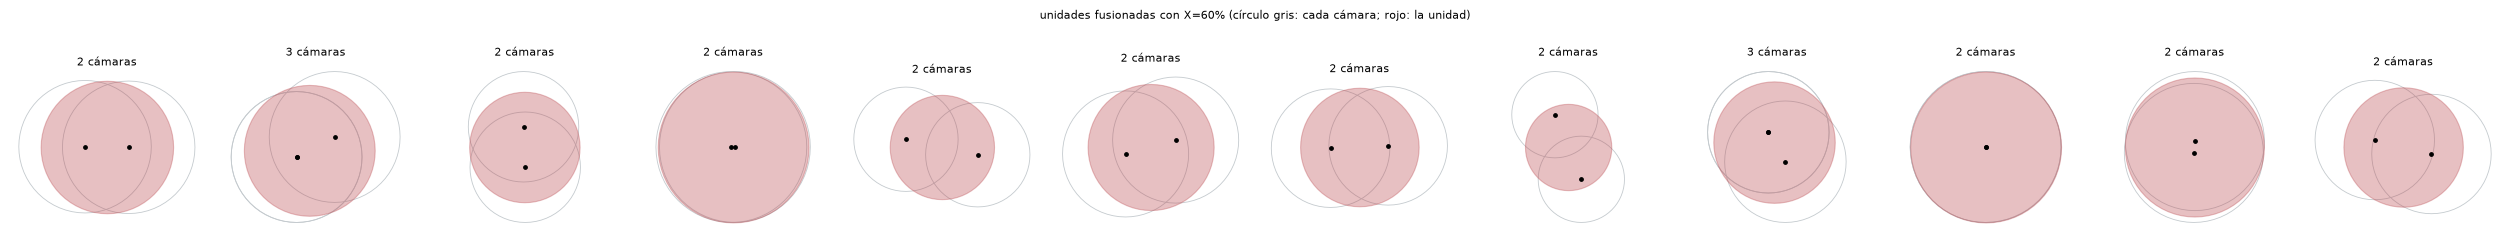

In [17]:
# cómo se ven las fusiones: cada grupo con más de una cámara, a RADIO_MAX
UMBRAL_VISTA = 0.6

etiquetas, _ = fusionar(datos.camaras, UMBRAL_VISTA)
centros = centros_de(datos.camaras, etiquetas)
fusionadas = centros[centros.n_camaras > 1]

fig, axes = plt.subplots(1, len(fusionadas), figsize=(2.1 * len(fusionadas), 2.4))
for ax, (_, unidad) in zip(np.atleast_1d(axes), fusionadas.iterrows()):
    ax.set_axis_off()
    ax.set_title(f"{unidad.n_camaras} cámaras", fontsize=8)
    miembros = datos.camaras[etiquetas == unidad.unidad_id]

    gpd.GeoSeries(miembros.geometry.buffer(RADIO_MIN), crs=datos.camaras.crs).plot(
        ax=ax, facecolor="none", edgecolor="#C4CACE", linewidth=.6
    )
    gpd.GeoSeries([unidad.geometry.buffer(RADIO_MIN)], crs=centros.crs).plot(
        ax=ax, facecolor="#BC4B51", alpha=.35, edgecolor="#BC4B51", linewidth=.8
    )
    miembros.plot(ax=ax, color="black", markersize=6)

fig.suptitle(f"unidades fusionadas con X={UMBRAL_VISTA:.0%} (círculo gris: cada cámara; rojo: la unidad)", fontsize=8)
fig.tight_layout()
plt.show()

## Decisión

**Radios: 100, 150, 200, 250 y 300 m.** El de 300 no es negociable porque es el
que sostiene la tesis; los demás sirven de robustez.

**Umbral de fusión: X = 60%, decidido a 300 m** (equivale a 192 m de distancia
entre cámaras). Deja 99 unidades de las 113 cámaras.

Por qué 60 y no otro:

- **Es el umbral más bajo que conserva la restricción.** Con X = 50% (242 m),
  dos cámaras quedan fuera del círculo de su propia unidad a 100 m. Con 60% la
  distancia máxima de una cámara a su centro es 81 m, con margen sobre los 100.
- **Elimina el traslape donde más duele.** A 100 m no queda ningún par
  traslapado y el conteo doble es 0.0%.
- **Bajar más no compra casi nada.** Entre 60% y 70% el conteo doble a 300 m
  pasa de 5.5% a 6.6%, pero 70% ya deja un par traslapado a 100 m.

Queda abierto el 5.5% de incidentes duplicados a 300 m, que es el precio de no
fusionar los pares que se traslapan por debajo del umbral.

### Unidades con la cámara al borde: prueba de robustez, no muestra principal

El centroide coincide con la cámara en 88 de las 99 unidades, porque son de una
sola cámara. Solo las 12 fusionadas pueden tener la cámara descentrada, y de
esas únicamente dos pasan de la mitad del radio a 100 m:

| Unidad | Cruces | Cámara más lejana | Incidentes a 100 m |
| --- | --- | --- | --- |
| 10 | Eje 1 Pte. Guerrero × Eje 2 Nte. Manuel González | 70 m | 215 |
| 26 | Eje 3 Pte. Thiers × Circuito Bicentenario Melchor Ocampo | 81 m | 276 |

Excluirlas cuesta 2 unidades, 4 cámaras y 2.9% de los incidentes tratados.

**Se quedan en la muestra principal.** La exclusión va como prueba de robustez,
reportando que los resultados no cambian al quitarlas, por tres razones:

1. **La regla no excluye al azar.** Solo pueden quedar descentradas las unidades
   fusionadas, así que excluir por cercanía al borde es excluir selectivamente
   por densidad de cámaras.
2. **Esas zonas parecen ser las de mayor siniestralidad.** Sus 215 y 276
   incidentes están por encima de la mediana (131) y de la media (171) por
   unidad. Si el programa puso dos cámaras cerca, probablemente fue porque el
   cruce lo ameritaba: quitarlas elimina los casos de tratamiento más intenso.
3. **Cambiaría el estimando.** Pasaría a ser el efecto en zonas con cámara
   excluyendo las de mayor densidad, y habría que declararlo. Es información que
   se reporta, no muestra que se descarta.

In [27]:
# qué tan al borde queda la cámara más lejana de cada unidad, medido contra el
# radio más chico, que es donde el círculo menos perdona
UMBRAL_ELEGIDO = 0.60

etiquetas, _ = fusionar(datos.camaras, UMBRAL_ELEGIDO)
centros = centros_de(datos.camaras, etiquetas)

centro_de_cada_camara = gpd.GeoSeries(centros.geometry.values[etiquetas])
distancia = np.hypot(
    datos.camaras.geometry.x.values - centro_de_cada_camara.x.values,
    datos.camaras.geometry.y.values - centro_de_cada_camara.y.values,
)

por_unidad = (
    pd.DataFrame({"unidad_id": etiquetas, "distancia_m": distancia})
    .groupby("unidad_id")
    .agg(n_camaras=("distancia_m", "size"), d_max_m=("distancia_m", "max"))
    .assign(pct_del_radio=lambda x: x.d_max_m / RADIO_MIN)
)

tabla = (
    pd.cut(
        por_unidad.pct_del_radio,
        bins=[0, .01, .25, .50, .75, 1.01],
        labels=["centrada (0%)", "0-25%", "25-50%", "50-75%", "75-100%"],
        include_lowest=True,
    )
    .value_counts()
    .sort_index()
    .rename("unidades")
    .to_frame()
    .rename_axis("cámara más lejana, como fracción del radio de 100 m")
)

print(f"{len(por_unidad)} unidades con X={UMBRAL_ELEGIDO:.0%}")
tabla

99 unidades con X=60%


,unidades
"cámara más lejana, como fracción del radio de 100 m",
centrada (0%),88
0-25%,2
25-50%,7
50-75%,1
75-100%,1


## Incidentes en áreas traslapadas

Con X=60% el traslape sobrevive solo en los radios grandes:

| Radio | Unidades afectadas | Incidentes duplicados |
| --- | --- | --- |
| 100 m | 0 | 0.0% |
| 150 m | 6 | 0.1% |
| 200 m | 14 | 1.2% |
| 250 m | 27 | 2.3% |
| 300 m | 36 | 5.5% |

**Decisión: repartir los incidentes compartidos.** Un incidente que cae en dos
círculos cuenta 1/2 en cada uno; en tres, 1/3. Con eso la suma de los conteos
por unidad deja de estar inflada y coincide exactamente con el número real de
incidentes: 44,153 a 300 m, contra 46,730 del conteo ingenuo.

A 300 m, 41,595 incidentes caen en un solo círculo y conservan peso 1; 2,539
caen en dos y 19 en tres o más. La regla se enuncia en una línea: *los
incidentes en áreas compartidas se reparten en partes iguales entre las unidades
que los contienen*.

**Lo que esto resuelve y lo que no.** Resuelve la aritmética: ninguna unidad
cuenta incidentes que no le corresponden. No resuelve que dos unidades vecinas
sigan registrando los mismos eventos a medias, así que sus resultados están
mecánicamente ligados. Con el 89% de los incidentes en peso 1, es un problema de
segundo orden, pero conviene mencionarlo al describir el diseño.

**Restricción técnica:** los pesos fraccionarios rompen los modelos de conteo
(Poisson, binomial negativa), que esperan enteros. Funcionan con MCO sobre
conteos o sobre tasas, que es la especificación del capítulo 2. Si en algún
momento se cambia a Poisson, hay que replantear esto.

**Como robustez:** partir el espacio por centro más cercano, asignando cada
incidente a una sola unidad. Cuesta 4.3% del área a 300 m y vuelve desiguales
las áreas, pero elimina el problema de raíz. Si los resultados aguantan, el
reparto no estaba cargando nada.

In [22]:
# qué unidades pierden más al repartir, y con quién comparten
RADIO_REPARTO = 300

circulos = gpd.GeoDataFrame(
    {"unidad_id": centros.unidad_id},
    geometry=centros.geometry.buffer(RADIO_REPARTO),
    crs=centros.crs,
)
asignados = gpd.sjoin(datos.incidentes, circulos, predicate="within")
veces = asignados.groupby(asignados.index).size()
asignados = asignados.assign(peso=1 / veces.reindex(asignados.index).values)

conteos = pd.DataFrame({
    "naive": asignados.groupby("unidad_id").size(),
    "ponderado": asignados.groupby("unidad_id").peso.sum(),
})
conteos["pct_compartido"] = 1 - conteos.ponderado / conteos.naive

conteos.sort_values("pct_compartido", ascending=False).head(8).style.format({
    "ponderado": "{:,.0f}", "naive": "{:,}", "pct_compartido": "{:.1%}",
})

,naive,ponderado,pct_compartido
unidad_id,,,
77,562,327,41.8%
32,578,343,40.7%
95,517,352,31.9%
71,429,295,31.2%
54,680,474,30.4%
81,419,294,29.9%
9,694,488,29.8%
88,631,500,20.8%


### El par que se quedó fuera por 13 metros

Las dos unidades que más pierden son las dos mitades del mismo par: la 77 pierde
41.8% de su conteo y la 32 pierde 40.7%. Comparten **57.3%** de su área a 300 m,
con los centros a **205 m**.

El umbral de X=60% corresponde a 192 m. **Se quedaron fuera de la fusión por 13
metros y 2.7 puntos porcentuales.**

Y son dos cámaras sobre el mismo tramo del mismo eje: Periférico segundo piso,
sentido sur-norte, una a la altura de Miguel Cabrera / La Castañeda y la otra en
Dr. González Herrejón / Lomas de Plateros. No son dos zonas distintas que se
rozan, es un mismo corredor partido en dos unidades.

Esto no invalida el umbral —cualquier corte deja casos pegados a la frontera—
pero hay que saber que existe:

- Si al final los resultados dependen de este par, es señal de que el umbral
  está haciendo demasiado trabajo.
- Vale la pena reportarlo como caso límite en el texto, y verificar en la
  robustez con X=50% (que sí los fusiona) que los coeficientes no se mueven.